In [1]:
# Libraries Import :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [2]:
# Dataset Load :
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(
                iris.target, iris.target_names)

print("Dataset loaded!")
print("Shape:", df.shape)
print("\nSpecies Distribution:")
print(df['species'].value_counts())
df.head()

Dataset loaded!
Shape: (150, 5)

Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Data Preprocessing :
# Features aur Target separate karo
X = df.drop('species', axis=1)
le = LabelEncoder()
y = le.fit_transform(df['species'])

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass mapping:")
for i, name in enumerate(le.classes_):
    print(f"{i}: {name}")

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTraining Set: {len(X_train)} rows")
print(f"Testing Set: {len(X_test)} rows")

Features shape: (150, 4)
Target shape: (150,)

Class mapping:
0: setosa
1: versicolor
2: virginica

Training Set: 120 rows
Testing Set: 30 rows


In [4]:
# Decision Tree Train :
print("TRAINING DECISION TREE MODEL")
print("="*40)

# Model banao
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=None)

# Train karo
dt_model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")

TRAINING DECISION TREE MODEL
Model trained successfully!
Tree Depth: 6
Number of Leaves: 10


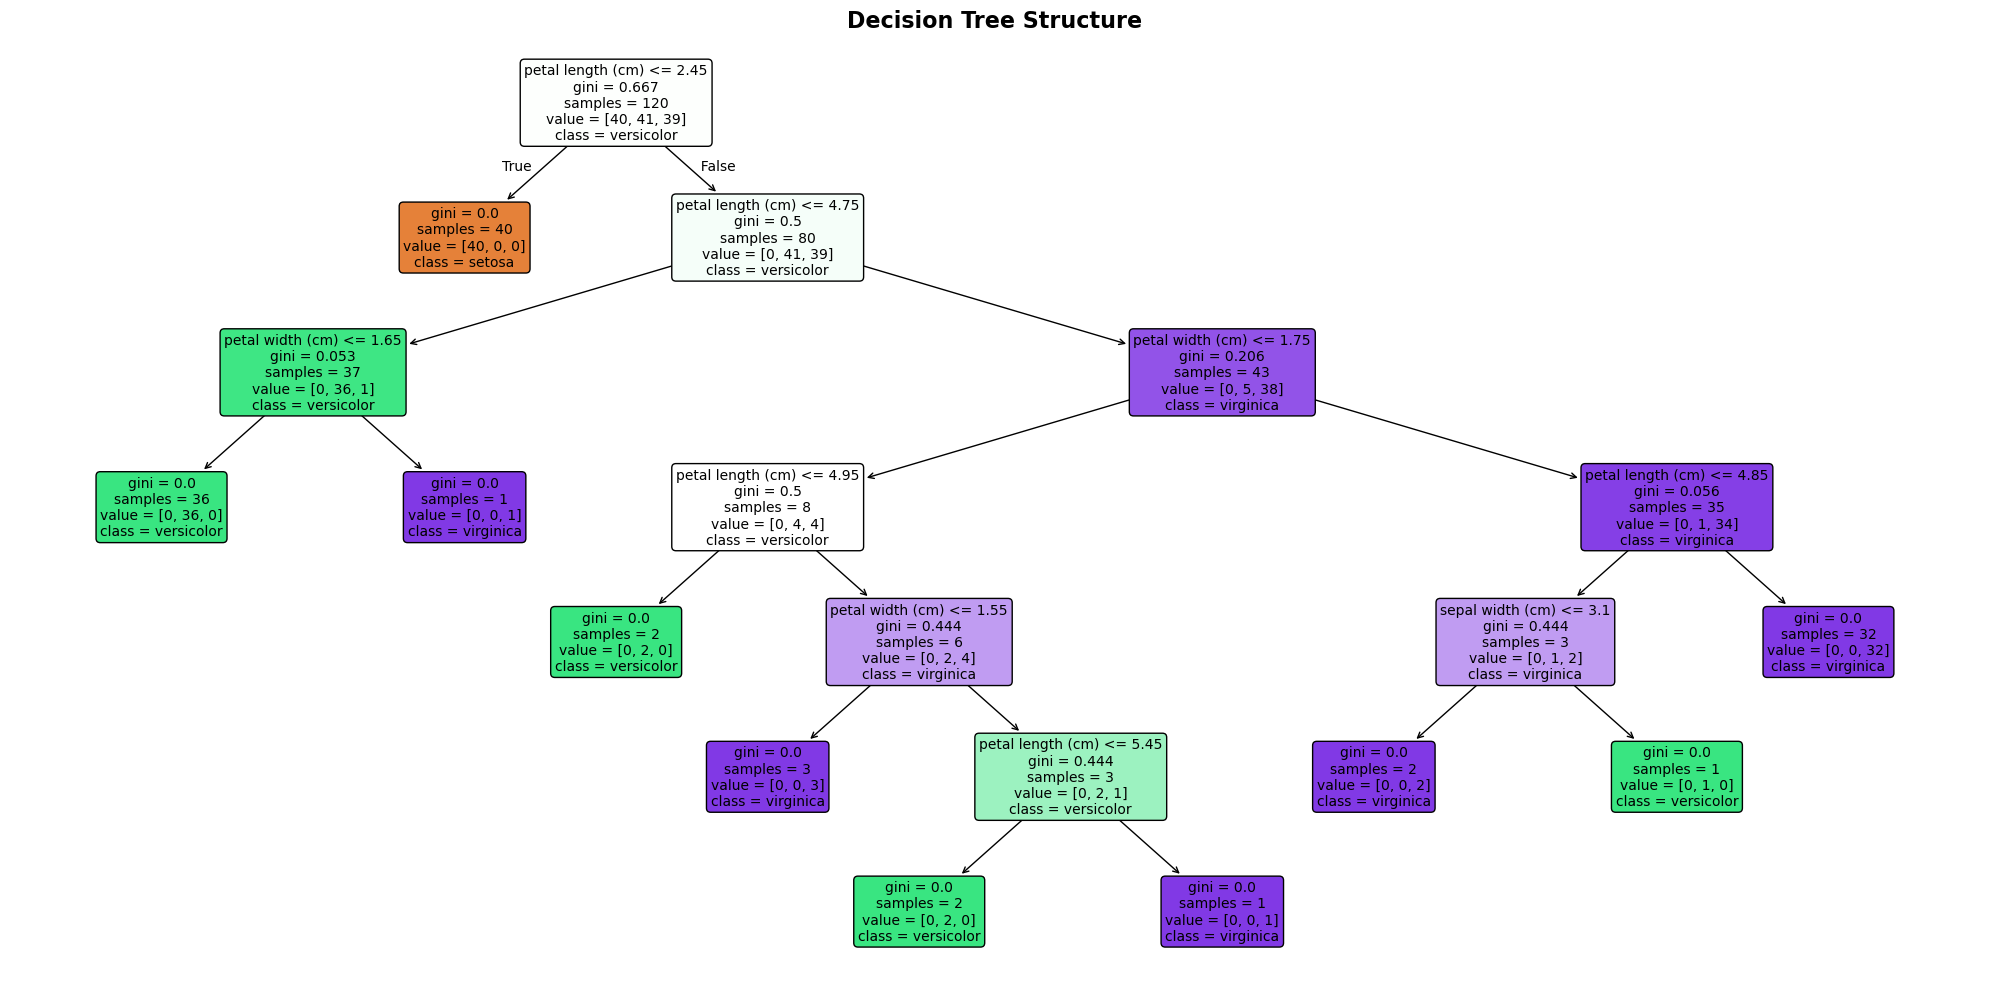

Decision tree saved!


In [5]:
# Train Visualize :
plt.figure(figsize=(20,10))
plot_tree(dt_model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Decision tree saved!")

In [6]:
# Model Evaluate :
y_pred = dt_model.predict(X_test)

print("MODEL EVALUATION — FULL TREE:")
print("="*40)
print(f"Accuracy: {round(accuracy_score(y_test, y_pred)*100,2)}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=iris.target_names))

MODEL EVALUATION — FULL TREE:
Accuracy: 100.0%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



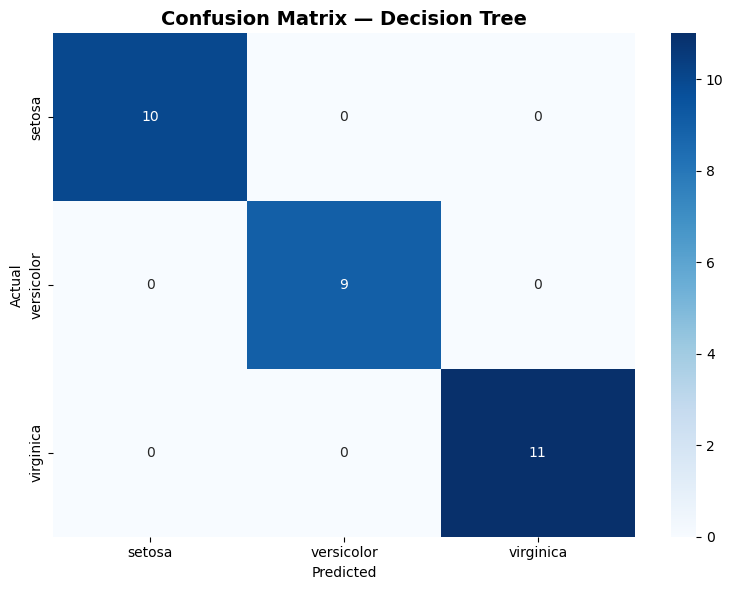

In [7]:
# Confusion Matrix :
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix — Decision Tree',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_dt.png', dpi=150)
plt.show()

PRUNING DECISION TREE


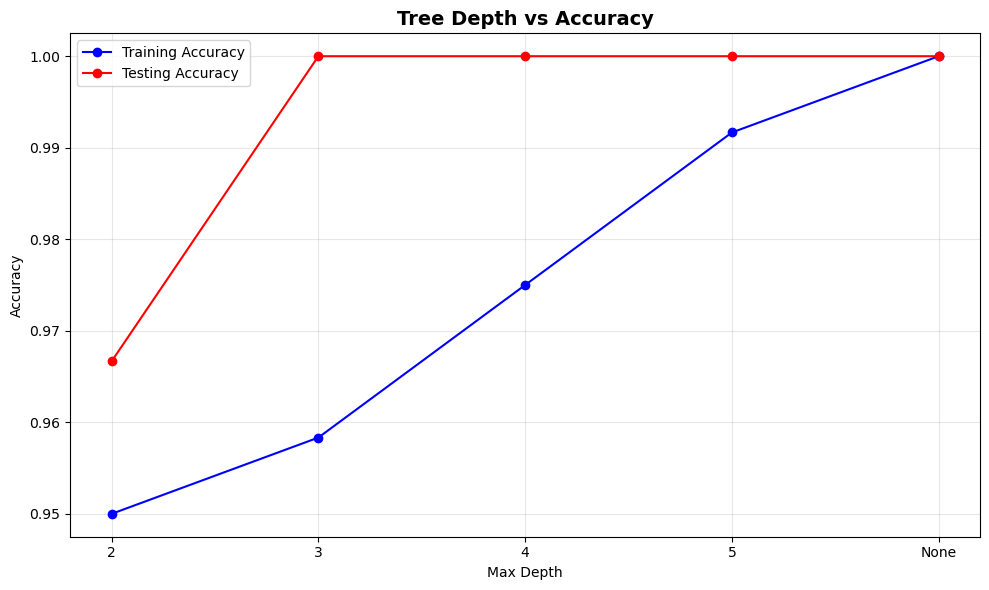

Depth 2: Train=95.0% Test=96.7%
Depth 3: Train=95.8% Test=100.0%
Depth 4: Train=97.5% Test=100.0%
Depth 5: Train=99.2% Test=100.0%
Depth None: Train=100.0% Test=100.0%


In [8]:
# Tree Pruning :
print("PRUNING DECISION TREE")
print("="*40)

# Different depths compare karo
depths = [2, 3, 4, 5, None]
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(
         max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(
        accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(
        accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(10,6))
depth_labels = [str(d) if d else 'None'
                for d in depths]
plt.plot(depth_labels, train_scores,
         'b-o', label='Training Accuracy')
plt.plot(depth_labels, test_scores,
         'r-o', label='Testing Accuracy')
plt.title('Tree Depth vs Accuracy',
          fontsize=14, fontweight='bold')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pruning_comparison.png', dpi=150)
plt.show()

for i, depth in enumerate(depths):
    d = str(depth) if depth else 'None'
    print(f"Depth {d}: Train={round(train_scores[i]*100,1)}% Test={round(test_scores[i]*100,1)}%")


PRUNED TREE EVALUATION (depth=3):
Accuracy: 100.0%


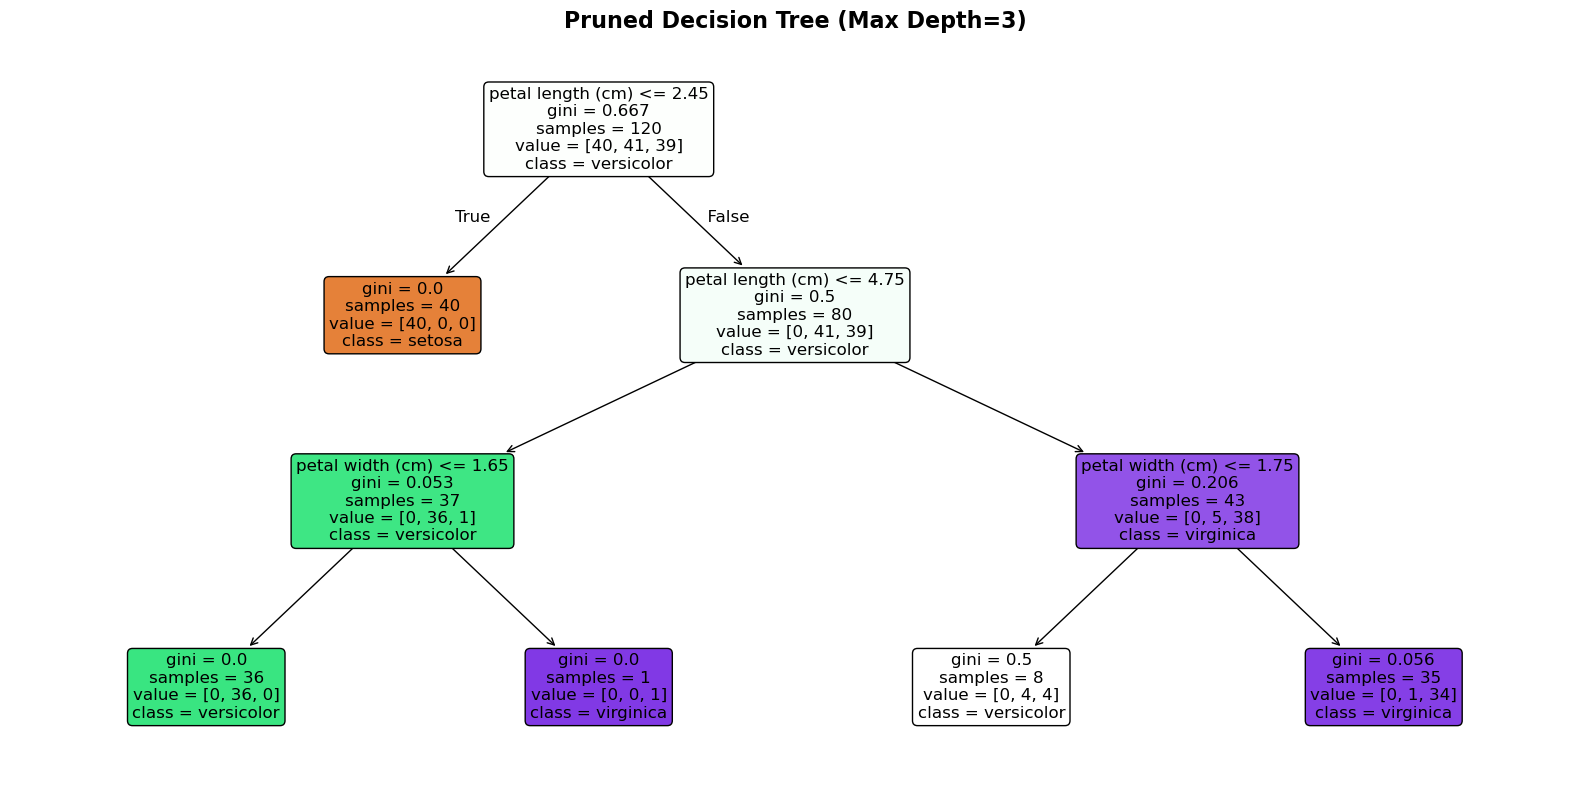

In [9]:
# Best Pruned Tree :
# Best depth se model banao
best_dt = DecisionTreeClassifier(
    max_depth=3, random_state=42)
best_dt.fit(X_train, y_train)
y_pred_best = best_dt.predict(X_test)

print("PRUNED TREE EVALUATION (depth=3):")
print("="*40)
print(f"Accuracy: {round(accuracy_score(y_test, y_pred_best)*100,2)}%")

# Pruned tree visualize karo
plt.figure(figsize=(16,8))
plot_tree(best_dt,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Pruned Decision Tree (Max Depth=3)',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pruned_tree.png',
            dpi=150, bbox_inches='tight')
plt.show()

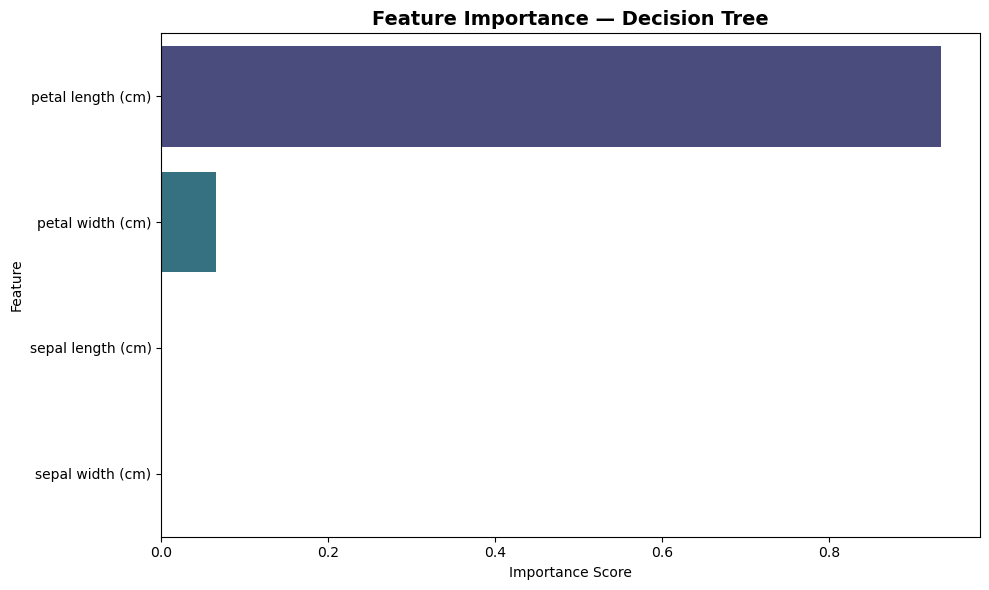

Feature Importance:
             Feature  Importance
2  petal length (cm)    0.934626
3   petal width (cm)    0.065374
0  sepal length (cm)    0.000000
1   sepal width (cm)    0.000000


In [10]:
# Feature Importance :
plt.figure(figsize=(10,6))
importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature',
            data=importance,
            palette='viridis')
plt.title('Feature Importance — Decision Tree',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Feature Importance:")
print(importance)

In [11]:
# Key Insights :
accuracy_full = accuracy_score(y_test, y_pred)*100
accuracy_pruned = accuracy_score(
                  y_test, y_pred_best)*100

print("KEY INSIGHTS:")
print("="*40)
print(f"1. Full Tree Accuracy: {round(accuracy_full,2)}%")
print(f"2. Pruned Tree Accuracy: {round(accuracy_pruned,2)}%")
print(f"3. Full Tree Depth: {dt_model.get_depth()}")
print(f"4. Pruned Tree Depth: 3")
print(f"5. Most Important Feature: {importance.iloc[0]['Feature']}")
print("\nBUSINESS INSIGHTS:")
print("- Petal features best for classification")
print("- Pruning prevents overfitting")
print("- Simple tree works as well as complex tree")
print("- Decision trees are easy to interpret")

KEY INSIGHTS:
1. Full Tree Accuracy: 100.0%
2. Pruned Tree Accuracy: 100.0%
3. Full Tree Depth: 6
4. Pruned Tree Depth: 3
5. Most Important Feature: petal length (cm)

BUSINESS INSIGHTS:
- Petal features best for classification
- Pruning prevents overfitting
- Simple tree works as well as complex tree
- Decision trees are easy to interpret
